#### Step1- Load Data

In [1]:

import pandas as pd

weekly_clean = pd.read_csv('../data/processed/weekly_clean.csv')
weekly_clean['week'] = pd.to_datetime(weekly_clean['week'])

weekly_clean.head()

,week,total_orders,total_return_proxy,avg_delivery_delay,return_rate
0,2016-10-03,283.0,85.0,-36.533898,0.300353
1,2017-01-16,197.0,25.0,-28.798942,0.126904
2,2017-01-23,354.0,61.0,-27.072289,0.172316
3,2017-01-30,467.0,71.0,-23.930556,0.152034
4,2017-02-06,548.0,70.0,-20.641879,0.127737


#### Step 2: Train/test split

In [2]:

# Split point: last 12 weeks = test, everything before = train
test_size = 12

train = weekly_clean.iloc[:-test_size].reset_index(drop=True)
test = weekly_clean.iloc[-test_size:].reset_index(drop=True)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train range:", train['week'].min(), "to", train['week'].max())
print("Test range:", test['week'].min(), "to", test['week'].max())

Train shape: (73, 5)
Test shape: (12, 5)
Train range: 2016-10-03 00:00:00 to 2018-05-28 00:00:00
Test range: 2018-06-04 00:00:00 to 2018-08-20 00:00:00


#### Step 3: SARIMA with auto_arima(auto detects ,p,d,q values)pick the one that fits train best

In [3]:

from pmdarima import auto_arima

model_sarima = auto_arima(
    train['total_return_proxy'],
    seasonal=True,
    m=13,              # approx seasonal cycle length in weeks (informed by the lag-14 hint from Phase 2)
    d=1,               # we confirmed 1 round of differencing is needed
    trace=True,        # prints each combination it tries
    suppress_warnings=True,
    stepwise=True      # smarter, faster search instead of brute-forcing every combination
)

print(model_sarima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[13] intercept   : AIC=inf, Time=1.32 sec
 ARIMA(0,1,0)(0,0,0)[13] intercept   : AIC=827.357, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[13] intercept   : AIC=830.911, Time=0.41 sec
 ARIMA(0,1,1)(0,0,1)[13] intercept   : AIC=830.699, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[13]             : AIC=825.358, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[13] intercept   : AIC=829.249, Time=0.15 sec
 ARIMA(0,1,0)(0,0,1)[13] intercept   : AIC=829.179, Time=0.17 sec
 ARIMA(0,1,0)(1,0,1)[13] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(1,1,0)(0,0,0)[13] intercept   : AIC=829.091, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[13] intercept   : AIC=829.026, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[13] intercept   : AIC=inf, Time=0.34 sec

Best model:  ARIMA(0,1,0)(0,0,0)[13]          
Total fit time: 3.379 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   73
Model: 

In [4]:
# Find the week with the highest return-proxy count (our suspected Black Friday spike)
spike_week = weekly_clean.loc[weekly_clean['total_return_proxy'].idxmax(), 'week']
print("Spike week:", spike_week)
print(weekly_clean.loc[weekly_clean['total_return_proxy'].idxmax()])

Spike week: 2017-11-20 00:00:00
week                  2017-11-20 00:00:00
total_orders                       3008.0
total_return_proxy                  654.0
avg_delivery_delay               -6.55506
return_rate                       0.21742
Name: 45, dtype: object


In [5]:
train = train.copy()
test = test.copy()

train['is_spike_week'] = (train['week'] == '2017-11-20').astype(int)
test['is_spike_week'] = (test['week'] == '2017-11-20').astype(int)

print(train['is_spike_week'].sum())  # should be 1 (one flagged week in train)
print(test['is_spike_week'].sum())   # should be 0 (no flagged week in test)

1
0


In [6]:
# Rebuild the model as SARIMAX (with the spike flag)
from pmdarima import auto_arima

model_sarimax = auto_arima(
    train['total_return_proxy'],
    X=train[['is_spike_week']],
    seasonal=True,
    m=13,
    d=1,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(model_sarimax.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[13] intercept   : AIC=759.396, Time=1.50 sec
 ARIMA(0,1,0)(0,0,0)[13] intercept   : AIC=766.523, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[13] intercept   : AIC=761.741, Time=0.67 sec
 ARIMA(0,1,1)(0,0,1)[13] intercept   : AIC=758.989, Time=0.69 sec
 ARIMA(0,1,0)(0,0,0)[13]             : AIC=764.526, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[13] intercept   : AIC=763.876, Time=0.24 sec
 ARIMA(0,1,1)(1,0,1)[13] intercept   : AIC=760.693, Time=1.01 sec
 ARIMA(0,1,1)(0,0,2)[13] intercept   : AIC=760.509, Time=1.47 sec
 ARIMA(0,1,1)(1,0,0)[13] intercept   : AIC=760.587, Time=0.52 sec
 ARIMA(0,1,1)(1,0,2)[13] intercept   : AIC=inf, Time=1.87 sec
 ARIMA(0,1,0)(0,0,1)[13] intercept   : AIC=762.662, Time=0.32 sec
 ARIMA(1,1,1)(0,0,1)[13] intercept   : AIC=760.954, Time=0.84 sec
 ARIMA(0,1,2)(0,0,1)[13] intercept   : AIC=760.905, Time=0.91 sec
 ARIMA(1,1,0)(0,0,1)[13] intercept   : AIC=760.088, Time=0.60 sec
 ARIMA(1,1,2)(0,0,1)[13] intercept   

In [7]:
#forecast the test weeks with this improved model
n_periods = len(test)
forecast, conf_int = model_sarimax.predict(
    n_periods=n_periods,
    X=test[['is_spike_week']],
    return_conf_int=True
)

sarima_results = test[['week', 'total_return_proxy']].copy()
sarima_results['sarima_pred'] = forecast.values

sarima_results

,week,total_return_proxy,sarima_pred
0,2018-06-04,182.0,91.445391
1,2018-06-11,159.0,79.630930
2,2018-06-18,133.0,70.710150
3,2018-06-25,147.0,50.801021
4,2018-07-02,105.0,20.824862
5,2018-07-09,145.0,6.422979
6,2018-07-16,186.0,10.050099
7,2018-07-23,169.0,1.529976
8,2018-07-30,286.0,12.009356
9,2018-08-06,251.0,21.511449


In [8]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

mape_sarima = mean_absolute_percentage_error(sarima_results['total_return_proxy'], sarima_results['sarima_pred'])
rmse_sarima = np.sqrt(mean_squared_error(sarima_results['total_return_proxy'], sarima_results['sarima_pred']))

print(f"SARIMA MAPE: {mape_sarima:.2%}")
print(f"SARIMA RMSE: {rmse_sarima:.2f}")

SARIMA MAPE: 83.89%
SARIMA RMSE: 152.76


In [9]:
#Walk-forward forecasting + trend term
model_sarimax = auto_arima(
    train['total_return_proxy'],
    X=train[['is_spike_week']],
    seasonal=True,
    m=13,
    d=1,
    trend='t',          # <-- adds linear trend component
    trace=True,
    suppress_warnings=True,
    stepwise=True
)
print(model_sarimax.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[13] intercept   : AIC=758.610, Time=1.49 sec
 ARIMA(0,1,0)(0,0,0)[13] intercept   : AIC=766.456, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[13] intercept   : AIC=761.390, Time=0.28 sec
 ARIMA(0,1,1)(0,0,1)[13] intercept   : AIC=758.741, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[13]             : AIC=766.456, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[13] intercept   : AIC=756.971, Time=1.11 sec
 ARIMA(2,1,2)(0,0,0)[13] intercept   : AIC=763.131, Time=0.56 sec
 ARIMA(2,1,2)(0,0,2)[13] intercept   : AIC=758.346, Time=2.13 sec
 ARIMA(2,1,2)(1,0,0)[13] intercept   : AIC=759.460, Time=1.11 sec
 ARIMA(2,1,2)(1,0,2)[13] intercept   : AIC=inf, Time=2.66 sec
 ARIMA(1,1,2)(0,0,1)[13] intercept   : AIC=inf, Time=1.09 sec
 ARIMA(2,1,1)(0,0,1)[13] intercept   : AIC=757.163, Time=1.12 sec
 ARIMA(3,1,2)(0,0,1)[13] intercept   : AIC=759.582, Time=1.55 sec
 ARIMA(2,1,3)(0,0,1)[13] intercept   : AIC=758.907, Time=1.46 sec
 ARIMA(1,1,1)(0,0,1)[13] intercept   : AI

In [10]:
history = train['total_return_proxy'].tolist()
history_spike = train['is_spike_week'].tolist()
predictions = []

for i in range(len(test)):
    # Refit-free rolling forecast: predict 1 step ahead using the model, then append the real value
    model_step = auto_arima(
        history, X=np.array(history_spike).reshape(-1,1),
        seasonal=True, m=13, d=1, trend='t',
        suppress_warnings=True, stepwise=True
    )
    next_spike = [[test['is_spike_week'].iloc[i]]]
    pred = model_step.predict(n_periods=1, X=next_spike)[0]
    predictions.append(pred)
    
    # Append the REAL actual value (not the prediction) before forecasting the next week
    history.append(test['total_return_proxy'].iloc[i])
    history_spike.append(test['is_spike_week'].iloc[i])

sarima_results = test[['week', 'total_return_proxy']].copy()
sarima_results['sarima_pred'] = predictions
sarima_results

,week,total_return_proxy,sarima_pred
0,2018-06-04,182.0,88.647712
1,2018-06-11,159.0,239.194517
2,2018-06-18,133.0,153.627854
3,2018-06-25,147.0,111.706368
4,2018-07-02,105.0,120.111881
5,2018-07-09,145.0,71.689841
6,2018-07-16,186.0,164.717937
7,2018-07-23,169.0,183.177954
8,2018-07-30,286.0,182.745581
9,2018-08-06,251.0,323.000923


In [11]:
mape_sarima = mean_absolute_percentage_error(sarima_results['total_return_proxy'], sarima_results['sarima_pred'])
rmse_sarima = np.sqrt(mean_squared_error(sarima_results['total_return_proxy'], sarima_results['sarima_pred']))

print(f"SARIMA (walk-forward) MAPE: {mape_sarima:.2%}")
print(f"SARIMA (walk-forward) RMSE: {rmse_sarima:.2f}")

SARIMA (walk-forward) MAPE: 29.11%
SARIMA (walk-forward) RMSE: 60.27


#### Step 4: XGBoost
XGBoost doesn't understand "time" at all — it just sees rows of features and predicts a number. So instead of feeding it a sequence, we manually construct features that encode time-related patterns: what happened last week, 2 weeks ago, what month it is, etc. This is called feature engineering — turning "time" into explicit, learnable inputs.

In [16]:
#Build lag and calendar features
xgb_data = weekly_clean.copy()

# Lag features — value from 1, 2, 3 weeks ago
xgb_data['lag_1'] = xgb_data['total_return_proxy'].shift(1)
xgb_data['lag_2'] = xgb_data['total_return_proxy'].shift(2)
xgb_data['lag_3'] = xgb_data['total_return_proxy'].shift(3)

# Rolling average — smoothed recent trend (last 4 weeks)
xgb_data['rolling_mean_4'] = xgb_data['total_return_proxy'].shift(1).rolling(4).mean()

# Calendar features — month and week-of-year capture seasonality
xgb_data['month'] = xgb_data['week'].dt.month
xgb_data['weekofyear'] = xgb_data['week'].dt.isocalendar().week.astype(int)

# Spike flag (same concept as SARIMA)
xgb_data['is_spike_week'] = (xgb_data['week'] == '2017-11-20').astype(int)

# Drop early rows where lag features are NaN (no history yet)
xgb_data = xgb_data.dropna().reset_index(drop=True)

print(xgb_data.shape)
xgb_data.head()

(81, 12)


,week,total_orders,total_return_proxy,avg_delivery_delay,return_rate,lag_1,lag_2,lag_3,rolling_mean_4,month,weekofyear,is_spike_week
0,2017-02-06,548.0,70.0,-20.641879,0.127737,71.0,61.0,25.0,60.50,2,6,0
1,2017-02-13,411.0,82.0,-20.269129,0.199513,70.0,71.0,61.0,56.75,2,7,0
2,2017-02-20,379.0,68.0,-15.094556,0.179420,82.0,70.0,71.0,71.00,2,8,0
3,2017-02-27,497.0,72.0,-11.928416,0.144869,68.0,82.0,70.0,72.75,2,9,0
4,2017-03-06,582.0,91.0,-11.529197,0.156357,72.0,68.0,82.0,73.00,3,10,0


In [17]:
#Re-split into train/test (same 12-week test window)(need same exct test weeks as SARIMA)
test_size = 12

xgb_train = xgb_data.iloc[:-test_size].reset_index(drop=True)
xgb_test = xgb_data.iloc[-test_size:].reset_index(drop=True)

print("XGB Train range:", xgb_train['week'].min(), "to", xgb_train['week'].max())
print("XGB Test range:", xgb_test['week'].min(), "to", xgb_test['week'].max())
print("Train shape:", xgb_train.shape, "Test shape:", xgb_test.shape)

XGB Train range: 2017-02-06 00:00:00 to 2018-05-28 00:00:00
XGB Test range: 2018-06-04 00:00:00 to 2018-08-20 00:00:00
Train shape: (69, 12) Test shape: (12, 12)


In [18]:
#Train XGBoost and forecast the test weeks
from xgboost import XGBRegressor

feature_cols = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_4', 'month', 'weekofyear', 'is_spike_week']

X_train = xgb_train[feature_cols]
y_train = xgb_train['total_return_proxy']

X_test = xgb_test[feature_cols]
y_test = xgb_test['total_return_proxy']

model_xgb = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
model_xgb.fit(X_train, y_train)

xgb_preds = model_xgb.predict(X_test)

xgb_results = xgb_test[['week', 'total_return_proxy']].copy()
xgb_results['xgb_pred'] = xgb_preds
xgb_results

,week,total_return_proxy,xgb_pred
0,2018-06-04,182.0,136.167831
1,2018-06-11,159.0,193.340851
2,2018-06-18,133.0,134.400314
3,2018-06-25,147.0,131.700958
4,2018-07-02,105.0,154.965073
5,2018-07-09,145.0,126.102554
6,2018-07-16,186.0,141.179596
7,2018-07-23,169.0,187.451569
8,2018-07-30,286.0,148.358002
9,2018-08-06,251.0,252.571930


In [19]:
mape_xgb = mean_absolute_percentage_error(xgb_results['total_return_proxy'], xgb_results['xgb_pred'])
rmse_xgb = np.sqrt(mean_squared_error(xgb_results['total_return_proxy'], xgb_results['xgb_pred']))

print(f"XGBoost MAPE: {mape_xgb:.2%}")
print(f"XGBoost RMSE: {rmse_xgb:.2f}")

XGBoost MAPE: 20.93%
XGBoost RMSE: 49.57


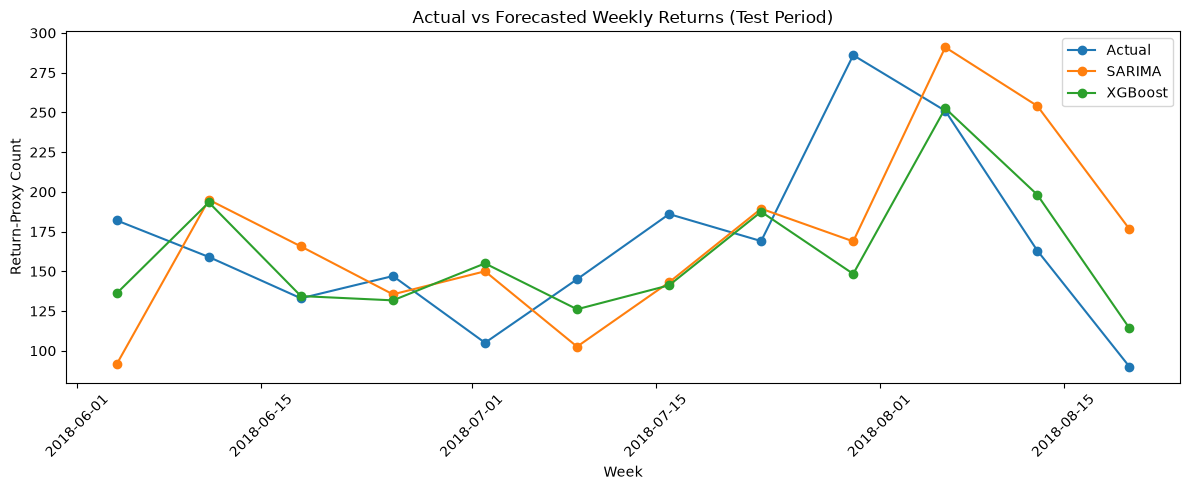

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(xgb_test['week'], xgb_test['total_return_proxy'], label='Actual', marker='o')
plt.plot(sarima_results['week'], sarima_results['sarima_pred'], label='SARIMA', marker='o')
plt.plot(xgb_results['week'], xgb_results['xgb_pred'], label='XGBoost', marker='o')
plt.title('Actual vs Forecasted Weekly Returns (Test Period)')
plt.xlabel('Week')
plt.ylabel('Return-Proxy Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()